# PDM Metric Comparison (Two Agents)

This notebook draws a single bar chart that compares PDM sub-metrics for two agents on the same scene.

In [40]:
# Inputs: replace with real results from your two agents.
# The dict keys should match PDMResult fields.
agent_a_name = "Transfuser"
agent_b_name = "Fusionad"

# Example placeholders; replace with actual values (0-1).
agent_a_result = {
    "no_at_fault_collisions": 1.000,
    "drivable_area_compliance": 1.000,
    "ego_progress": 0.819,
    "time_to_collision_within_bound": 1.000,
    "comfort": 1.000,
    "driving_direction_compliance": 1.000,
    "score": 0.925,
}
agent_b_result = {
    "no_at_fault_collisions": 1.000,
    "drivable_area_compliance": 1.000,
    "ego_progress": 0.927,
    "time_to_collision_within_bound": 1.000,
    "comfort": 1.000,
    "driving_direction_compliance": 1.000,
    "score": 0.970,
}

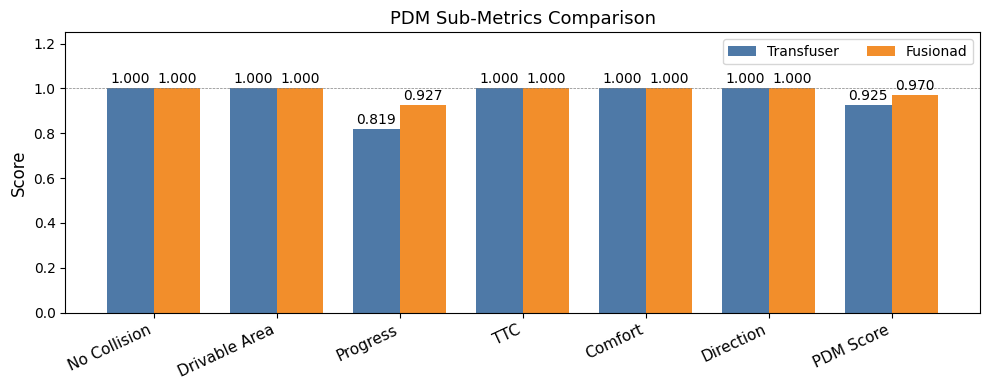

In [41]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = [
    "no_at_fault_collisions",
    "drivable_area_compliance",
    "ego_progress",
    "time_to_collision_within_bound",
    "comfort",
    "driving_direction_compliance",
    "score",
]
labels = [
    "No Collision",
    "Drivable Area",
    "Progress",
    "TTC",
    "Comfort",
    "Direction",
    "PDM Score",
]

vals_a = [agent_a_result[n] for n in metric_names]
vals_b = [agent_b_result[n] for n in metric_names]

x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 4))
bars_a = ax.bar(x - width / 2, vals_a, width, label=agent_a_name, color="#4e79a7")
bars_b = ax.bar(x + width / 2, vals_b, width, label=agent_b_name, color="#f28e2b")

for bar, val in zip(bars_a, vals_a):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
for bar, val in zip(bars_b, vals_b):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("PDM Sub-Metrics Comparison", fontsize=13)
ax.set_ylim(0, 1.25)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.5)
ax.legend(loc="upper right", fontsize=10, ncol=2)

fig.tight_layout()
plt.show()